<a href="https://colab.research.google.com/github/AntonRize/WILL/blob/main/Colab_Notebooks/ROMvsGR_S2_study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

>>> Loading raw data from GitHub...
>>> Phase 1: Global search (Nelder-Mead)...
>>> Phase 2: Precision refinement (L-BFGS-B)...

WILL RELATIONAL GEOMETRY: FULL OPTICAL + ROMER SOLUTION
Fit Quality (Chi-Squared):       727.2044
Number of Observables:           174
-----------------------------------------------------------------
Relational Beta (beta):          0.00642627
Angular Semi-major Axis (a_as):  0.124120 arcsec
Eccentricity (e):                0.887171
Inclination (i):                 2.377080 rad
Argument of Periapsis (omega):   1.162905 rad
Period (T):                      5862.4861 days
Derived Precession (f_prec):     0.00058183
Systemic Velocity (V0):          -15.5462 km/s
-----------------------------------------------------------------
DERIVED PHYSICAL PARAMETERS (FROM T and BETA ONLY):
Schwarzschild Radius (Rs):       12827524.71 km
Semi-major Axis (a):             1038.173191 AU
Distance to Sgr A* (R0):         8364.24 pc
----------------------------------------------

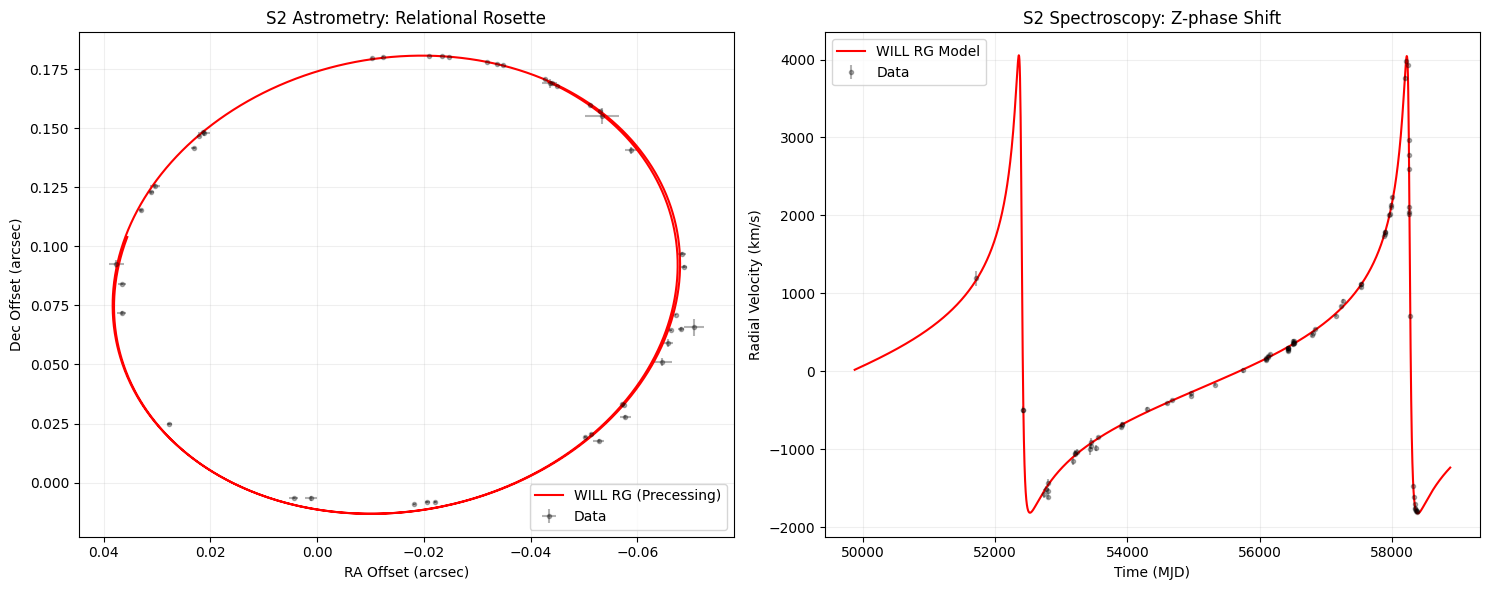

In [ ]:
"""
WILL Relational Geometry: S2 Relational Orbital Mechanics (R.O.M.)
Author: Anton Rize
Version: 1.4 (Strict Relational with Rømer Delay & Relational Redshift)

"""

import numpy as np
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt

# --- 1. GLOBAL CONSTANTS ---
C_KMS = 299792.458
AU_KM = 149597870.7
MSUN_GM = (1.32712440018e20 / (C_KMS*1000)**2) / 1000

# --- 2. DATA LOADING (Raw URLs) ---
URL_ASTRO = 'https://raw.githubusercontent.com/AntonRize/WILL/main/DATA/aav8137_data_s2.csv'
URL_RV = 'https://raw.githubusercontent.com/AntonRize/WILL/main/DATA/S0-2_DataS1_full.csv'

print(">>> Loading raw data from GitHub...")
df_astro = pd.read_csv(URL_ASTRO).sort_values('mjd')
df_rv = pd.read_csv(URL_RV).sort_values('MJD')

m_a = df_astro['mjd'].values
x_obs, x_err = df_astro['x'].values, df_astro['xerr'].values
y_obs, y_err = df_astro['y'].values, df_astro['yerr'].values

m_r = df_rv['MJD'].values
rv_obs, rv_err = df_rv['RV_km_s'].values, df_rv['sigma_km_s'].values

# --- 3. RELATIONAL ALGORITHMS ---

def solve_kepler(M, e):
    E = np.copy(M)
    for _ in range(50):
        E = E - (E - e * np.sin(E) - M) / (1 - e * np.cos(E))
    return E

def get_nu(mjd, T0, P, e):
    M = 2 * np.pi * (mjd - T0) / P
    orbits = np.floor(M / (2 * np.pi))
    M_mod = M % (2 * np.pi)
    E_mod = solve_kepler(M_mod, e)
    nu_mod = 2 * np.arctan2(np.sqrt(1 + e) * np.sin(E_mod / 2), np.sqrt(1 - e) * np.cos(E_mod / 2))
    return orbits * 2 * np.pi + (nu_mod % (2 * np.pi))

def will_model_strict(params, mjd_a, mjd_r):
    a_as, e, i, omega, Omega, P, T0, V0, K = params

    # [ALGEBRAIC LOCK & SCALE]
    beta_int = (K / C_KMS) / np.sin(i)
    beta_sq = (beta_int**2) * (1 - e**2)
    tau_Y_sq = 3 * beta_sq - 2 * (beta_sq**2)
    f_prec = tau_Y_sq / (1 - e**2)

    beta = np.sqrt(beta_sq)
    T_sec = P * 86400
    Rs_km = (T_sec * C_KMS * (beta**3)) / np.pi
    a_km = Rs_km / (2 * beta_sq)
    scale_km_per_as = a_km / a_as

    # --- ASTROMETRY WITH ROMER DELAY ---
    nu_a_0 = get_nu(mjd_a, T0, P, e)
    w_shift_a_0 = f_prec * nu_a_0
    r_O_0 = a_as * (1 - e**2) / (1 + e * np.cos(nu_a_0 - w_shift_a_0))
    z_km_a = r_O_0 * scale_km_per_as * np.sin(i) * np.sin(nu_a_0 + omega + w_shift_a_0)

    t_emit_a = mjd_a - z_km_a / (C_KMS * 86400)

    nu_a = get_nu(t_emit_a, T0, P, e)
    w_shift_a = f_prec * nu_a
    r_O = a_as * (1 - e**2) / (1 + e * np.cos(nu_a - w_shift_a))
    x_orb = r_O * np.cos(nu_a)
    y_orb = r_O * np.sin(nu_a)

    A = np.cos(Omega)*np.cos(omega) - np.sin(Omega)*np.sin(omega)*np.cos(i)
    B = np.sin(Omega)*np.cos(omega) + np.cos(Omega)*np.sin(omega)*np.cos(i)
    F = -np.cos(Omega)*np.sin(omega) - np.sin(Omega)*np.cos(omega)*np.cos(i)
    G = -np.sin(Omega)*np.sin(omega) + np.cos(Omega)*np.cos(omega)*np.cos(i)

    x_sky = B * x_orb + G * y_orb
    y_sky = A * x_orb + F * y_orb

    # --- RADIAL VELOCITY WITH ROMER & RELATIONAL REDSHIFT ---
    rv_pred = np.array([])
    if len(mjd_r) > 0:
        nu_r_0 = get_nu(mjd_r, T0, P, e)
        w_shift_r_0 = f_prec * nu_r_0
        r_O_r_0 = a_as * (1 - e**2) / (1 + e * np.cos(nu_r_0 - w_shift_r_0))
        z_km_r = r_O_r_0 * scale_km_per_as * np.sin(i) * np.sin(nu_r_0 + omega + w_shift_r_0)

        t_emit_r = mjd_r - z_km_r / (C_KMS * 86400)

        nu_r = get_nu(t_emit_r, T0, P, e)
        w_shift_r = f_prec * nu_r
        eff_w = omega + w_shift_r

        # 1. Classical Doppler z-projection
        vz_classical = K * (np.cos(nu_r + eff_w) + e * np.cos(eff_w))

        # 2. WILL Relational Redshift (Z_sys)
        r_km_r = a_km * (1 - e**2) / (1 + e * np.cos(nu_r - w_shift_r))
        kappa_o_sq = Rs_km / r_km_r
        beta_o_sq = kappa_o_sq - beta_sq
        v_relational = C_KMS * (kappa_o_sq + beta_o_sq) / 2

        rv_pred = V0 + vz_classical + v_relational

    return x_sky, y_sky, rv_pred, beta_sq, f_prec

def objective(p):
    xs, ys, rv, _, _ = will_model_strict(p, m_a, m_r)
    return np.sum(((x_obs-xs)/x_err)**2) + np.sum(((y_obs-ys)/y_err)**2) + np.sum(((rv_obs-rv)/rv_err)**2)

# --- 4. EXECUTE OPTIMIZATION ---
# Widened bounds to prevent trapping
p0 = [0.124, 0.885, 2.36, 1.15, 3.98, 5860, 58258, -10.0, 3000]
bounds = [(0.10, 0.15), (0.80, 0.95), (0, np.pi), (0, 2*np.pi), (0, 2*np.pi),
          (5800, 5950), (58100, 58400), (-200, 200), (1000, 5000)]

print(">>> Phase 1: Global search (Nelder-Mead)...")
res_nm = minimize(objective, p0, bounds=bounds, method='Nelder-Mead', options={'maxiter': 25000})

print(">>> Phase 2: Precision refinement (L-BFGS-B)...")
res = minimize(objective, res_nm.x, bounds=bounds, method='L-BFGS-B')

# --- 5. POST-FIT RELATIONAL DERIVATION ---
a_as, e, i, omega, Omega, P_days, T0, V0, K = res.x
chi2_val = res.fun
_, _, _, beta_sq, f_prec = will_model_strict(res.x, np.array([T0]), np.array([]))

beta = np.sqrt(beta_sq)
T_sec = P_days * 86400
Rs_km = (T_sec * C_KMS * (beta**3)) / np.pi
a_km = Rs_km / (2 * beta_sq)
a_au = a_km / AU_KM
R0_pc = (a_km / a_as) / 3.08567758e13 * (180*3600/np.pi)
Mass_Msun = (Rs_km / 2) / MSUN_GM

# --- 6. SCIENTIFIC OUTPUT ---
print("\n" + "="*65)
print("WILL RELATIONAL GEOMETRY: FULL OPTICAL + ROMER SOLUTION")
print("="*65)
print(f"Fit Quality (Chi-Squared):       {chi2_val:.4f}")
print(f"Number of Observables:           {len(x_obs)*2 + len(rv_obs)}")
print("-" * 65)
print(f"Relational Beta (beta):          {beta:.8f}")
print(f"Angular Semi-major Axis (a_as):  {a_as:.6f} arcsec")
print(f"Eccentricity (e):                {e:.6f}")
print(f"Inclination (i):                 {i:.6f} rad")
print(f"Argument of Periapsis (omega):   {omega:.6f} rad")
print(f"Period (T):                      {P_days:.4f} days")
print(f"Derived Precession (f_prec):     {f_prec:.8f}")
print(f"Systemic Velocity (V0):          {V0:.4f} km/s")
print("-" * 65)
print("DERIVED PHYSICAL PARAMETERS (FROM T and BETA ONLY):")
print(f"Schwarzschild Radius (Rs):       {Rs_km:.2f} km")
print(f"Semi-major Axis (a):             {a_au:.6f} AU")
print(f"Distance to Sgr A* (R0):         {R0_pc:.2f} pc")
print("-" * 65)
print(f"Final Calculated Mass (M):       {Mass_Msun/1e6:.4f} Million M_sun")
print("="*65)

# --- 7. PLOTTING ---
m_dense = np.linspace(min(m_a.min(), m_r.min()), max(m_a.max(), m_r.max()) + 500, 2000)
xs_d, ys_d, rv_d, _, _ = will_model_strict(res.x, m_dense, m_dense)

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.errorbar(x_obs, y_obs, xerr=x_err, yerr=y_err, fmt='k.', alpha=0.3, label='Data')
plt.plot(xs_d, ys_d, 'r-', label='WILL RG (Precessing)')
plt.gca().invert_xaxis()
plt.xlabel('RA Offset (arcsec)')
plt.ylabel('Dec Offset (arcsec)')
plt.title('S2 Astrometry: Relational Rosette')
plt.legend()
plt.grid(True, alpha=0.2)

plt.subplot(1, 2, 2)
plt.errorbar(m_r, rv_obs, yerr=rv_err, fmt='k.', alpha=0.3, label='Data')
plt.plot(m_dense, rv_d, 'r-', label='WILL RG Model')
plt.xlabel('Time (MJD)')
plt.ylabel('Radial Velocity (km/s)')
plt.title('S2 Spectroscopy: Z-phase Shift')
plt.legend()
plt.grid(True, alpha=0.2)
print("Full WILL parameters:", res.x)

plt.tight_layout()
plt.show()

In [ ]:
"""
GR 1PN Fit for S2 – Compatible with WILL Methodology
------------------------------------------------------
9 free parameters (same as WILL):
  a_as, e, i, ω0, Ω, P, T0, V0, K

Omitted to match WILL:
  - No Shapiro delay
  - Single‑step Rømer delay (same as WILL)
  - No gravitational lensing

Precession: secular 1PN advance Δω/orbit = 6π (K/c)² / sin²i
Derived (post‑fit): M_BH, R0
"""

import numpy as np
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------
# Constants (SI & convenient units)
# ----------------------------------------------------------------------
C_KMS = 299792.458          # km/s
DAY_SEC = 86400.0
ARCSEC_TO_RAD = np.pi / (180.0 * 3600.0)

# ----------------------------------------------------------------------
# Load data (same as WILL)
# ----------------------------------------------------------------------
URL_ASTRO = 'https://raw.githubusercontent.com/AntonRize/WILL/main/DATA/aav8137_data_s2.csv'
URL_RV    = 'https://raw.githubusercontent.com/AntonRize/WILL/main/DATA/S0-2_DataS1_full.csv'

df_astro = pd.read_csv(URL_ASTRO).sort_values('mjd')
df_rv    = pd.read_csv(URL_RV).sort_values('MJD')

t_astro = df_astro['mjd'].values
x_obs, x_err = df_astro['x'].values, df_astro['xerr'].values
y_obs, y_err = df_astro['y'].values, df_astro['yerr'].values

t_rv   = df_rv['MJD'].values
rv_obs, rv_err = df_rv['RV_km_s'].values, df_rv['sigma_km_s'].values

# ----------------------------------------------------------------------
# Kepler solver
# ----------------------------------------------------------------------
def solve_kepler(M, e):
    E = M + e * np.sin(M)
    for _ in range(20):
        E = E - (E - e * np.sin(E) - M) / (1.0 - e * np.cos(E))
    return E

def true_anomaly(mjd, T0, P, e):
    """MJD -> true anomaly (rad)"""
    M = 2.0 * np.pi * (mjd - T0) / P
    orbits = np.floor(M / (2.0 * np.pi))
    M_mod = M % (2.0 * np.pi)
    E_mod = solve_kepler(M_mod, e)
    nu_mod = 2.0 * np.arctan2(np.sqrt(1.0 + e) * np.sin(E_mod / 2.0),
                              np.sqrt(1.0 - e) * np.cos(E_mod / 2.0))
    return orbits * 2.0 * np.pi + (nu_mod % (2.0 * np.pi))

# ----------------------------------------------------------------------
# GR model (9 parameters, single‑step Rømer, no Shapiro/lensing)
# ----------------------------------------------------------------------
def gr_model_9params(params, mjd_astro, mjd_rv):
    a_as, e, i, omega0, Omega, P, T0, V0, K = params

    # ----- derived physical scale from kinematics (same as WILL algebra) -----
    # a_km from K (semi‑amplitude in km/s)
    a_km = (K * P * DAY_SEC * np.sqrt(1.0 - e**2)) / (2.0 * np.pi * np.sin(i))
    # GM from Kepler's 3rd law
    n = 2.0 * np.pi / (P * DAY_SEC)          # mean motion (rad/s)
    GM = n**2 * a_km**3                      # m³/s², with a_km in km -> 1e9 m³/s²
    GM_mks = GM * 1e9                        # convert to m³/s²
    c_ms = C_KMS * 1000.0

    # ----- 1PN secular precession (derived from K and i) -----
    # Δω per orbit = 6π (K/c)² / sin²i
    delta_omega_per_orbit = (6.0 * np.pi * (K / C_KMS)**2) / np.sin(i)**2
    omega_dot = delta_omega_per_orbit / P    # advance per day

    # ----- Helper to compute Rømer‑corrected state (single‑step, as WILL) -----
    def compute_state(mjd):
        # Step 1: estimate emission time using instantaneous z
        nu0 = true_anomaly(mjd, T0, P, e)
        omega_t = omega0 + omega_dot * (mjd - T0)
        r0 = a_km * (1.0 - e**2) / (1.0 + e * np.cos(nu0))
        z0 = r0 * np.sin(i) * np.sin(nu0 + omega_t)
        t_emit = mjd - z0 / (C_KMS * DAY_SEC)

        # Step 2: recompute state at this single‑step emission time
        nu = true_anomaly(t_emit, T0, P, e)
        omega_t = omega0 + omega_dot * (t_emit - T0)
        r = a_km * (1.0 - e**2) / (1.0 + e * np.cos(nu))
        z = r * np.sin(i) * np.sin(nu + omega_t)

        # in‑plane coordinates
        x_orb_km = r * np.cos(nu)
        y_orb_km = r * np.sin(nu)
        return x_orb_km, y_orb_km, z, r, nu, omega_t

    # ----- Astrometry -----
    x_mod = np.array([])
    y_mod = np.array([])
    if len(mjd_astro) > 0:
        states = [compute_state(t) for t in mjd_astro]
        x_orb_arr = np.array([s[0] for s in states])
        y_orb_arr = np.array([s[1] for s in states])
        omega_arr = np.array([s[5] for s in states])

        # projection onto sky
        cos_Om, sin_Om = np.cos(Omega), np.sin(Omega)
        cos_om, sin_om = np.cos(omega_arr), np.sin(omega_arr)
        cos_i = np.cos(i)

        A = cos_Om * cos_om - sin_Om * sin_om * cos_i
        B = sin_Om * cos_om + cos_Om * sin_om * cos_i
        F = -cos_Om * sin_om - sin_Om * cos_om * cos_i
        G = -sin_Om * sin_om + cos_Om * cos_om * cos_i

        x_sky_km = B * x_orb_arr + G * y_orb_arr
        y_sky_km = A * x_orb_arr + F * y_orb_arr

        # Scale: a_km (km) -> a_as (arcsec) -> pc, distance derived post‑fit
        # We need a scale factor km per arcsec at unknown distance;
        # we use the fitted a_as to set the scale: scale = a_km / a_as
        scale_km_per_as = a_km / a_as
        x_mod = x_sky_km / scale_km_per_as
        y_mod = y_sky_km / scale_km_per_as

    # ----- Radial velocity -----
    rv_mod = np.array([])
    if len(mjd_rv) > 0:
        states_rv = [compute_state(t) for t in mjd_rv]
        r_arr = np.array([s[3] for s in states_rv])
        nu_arr = np.array([s[4] for s in states_rv])
        omega_arr = np.array([s[5] for s in states_rv])

        # classical Keplerian component
        v_rad_kepler = K * (np.cos(nu_arr + omega_arr) + e * np.cos(omega_arr))

        # GR 1PN redshift (identical to WILL relational redshift)
        v2 = GM * (2.0 / r_arr - 1.0 / a_km)   # units: km²/s²
        z_grav = GM / (r_arr * c_ms**2 * 1e-6)  # dimensionless, GM in km³/s²? careful units
        # GM is in km³/s² (since a_km in km, n in rad/s). v² in km²/s².
        # z_grav = GM / (r * c^2)  (GM in km³/s², c in km/s => c^2 in km²/s²)
        z_grav = GM / (r_arr * C_KMS**2)
        z_td   = 0.5 * v2 / C_KMS**2
        redshift_km_s = C_KMS * (z_grav + z_td)

        rv_mod = V0 + v_rad_kepler + redshift_km_s

    return x_mod, y_mod, rv_mod

# ----------------------------------------------------------------------
# Objective
# ----------------------------------------------------------------------
def chi2(params):
    x_m, y_m, rv_m = gr_model_9params(params, t_astro, t_rv)
    chi2_ast = np.sum(((x_obs - x_m) / x_err)**2 + ((y_obs - y_m) / y_err)**2)
    chi2_rv = np.sum(((rv_obs - rv_m) / rv_err)**2)
    return chi2_ast + chi2_rv

# ----------------------------------------------------------------------
# Fit
# ----------------------------------------------------------------------
# initial guess (close to known values)
p0 = [0.124, 0.885, 2.36, 1.15, 3.98, 5860.0, 58258.0, -15.0, 3100.0]
bounds = [
    (0.10, 0.15),           # a_as
    (0.80, 0.95),           # e
    (0.0, np.pi),           # i
    (0.0, 2*np.pi),         # ω0
    (0.0, 2*np.pi),         # Ω
    (5800, 5950),           # P (days)
    (58100, 58400),         # T0 (MJD)
    (-200, 200),            # V0 (km/s)
    (1000, 5000)            # K (km/s)
]

print("Optimising GR 1PN model (9 parameters, matched methodology)...")
res_nm = minimize(chi2, p0, bounds=bounds, method='Nelder-Mead',
                  options={'maxiter': 25000})
res = minimize(chi2, res_nm.x, bounds=bounds, method='L-BFGS-B')

# ----------------------------------------------------------------------
# Post‑fit derivation
# ----------------------------------------------------------------------
a_as, e, i, omega0, Omega, P, T0, V0, K = res.x
a_km = (K * P * DAY_SEC * np.sqrt(1.0 - e**2)) / (2.0 * np.pi * np.sin(i))
n = 2.0 * np.pi / (P * DAY_SEC)
GM = n**2 * a_km**3    # km³/s²
M_kg = GM * 1e9 / 6.67430e-11   # convert to SI mass
M_Msun = M_kg / 1.98847e30
delta_omega = (6.0 * np.pi * (K / C_KMS)**2) / np.sin(i)**2
# distance: R0 (pc) = a_km / (a_as * ARCSEC_TO_RAD) / (pc per km)
pc_per_km = 1.0 / 3.085677581e13
R0_pc = (a_km / (a_as * ARCSEC_TO_RAD)) * pc_per_km

print("\n" + "="*65)
print("GR 1PN FIT (9 parameters, no Shapiro/lensing)")
print("="*65)
print(f"χ² = {res.fun:.2f}")
print("-"*65)
print(f"a (arcsec)          = {a_as:.6f}")
print(f"e                   = {e:.6f}")
print(f"i (rad)             = {i:.6f}")
print(f"ω₀ (rad)            = {omega0:.6f}")
print(f"Ω (rad)             = {Omega:.6f}")
print(f"P (days)            = {P:.4f}")
print(f"T₀ (MJD)            = {T0:.4f}")
print(f"V₀ (km/s)           = {V0:.4f}")
print(f"K (km/s)            = {K:.4f}")
print(f"Δω/orbit (rad)      = {delta_omega:.6f}")
print("-"*65)
print("DERIVED PHYSICAL QUANTITIES:")
print(f"M_BH (10⁶ M☉)       = {M_Msun/1e6:.4f}")
print(f"R₀ (pc)             = {R0_pc:.2f}")
print("="*65)

Optimising GR 1PN model (9 parameters, matched methodology)...

GR 1PN FIT (9 parameters, no Shapiro/lensing)
χ² = 800.81
-----------------------------------------------------------------
a (arcsec)          = 0.124488
e                   = 0.887826
i (rad)             = 2.370695
ω₀ (rad)            = 1.160650
Ω (rad)             = 3.987842
P (days)            = 5862.5978
T₀ (MJD)            = 58257.6592
V₀ (km/s)           = -15.0196
K (km/s)            = 2894.4022
Δω/orbit (rad)      = 0.003619
-----------------------------------------------------------------
DERIVED PHYSICAL QUANTITIES:
M_BH (10⁶ M☉)       = 4.2430
R₀ (pc)             = 8274.84



CHI-SQUARED BREAKDOWN
GR 1PN  χ²_ast = 601.80  χ²_rv = 199.01  total = 800.81
GR 2PN  χ²_ast = 601.76  χ²_rv = 199.04  total = 800.81
WILL  χ²_ast = 545.19  χ²_rv = 182.01  total = 727.20

RMS of model differences (GR1PN – WILL):
  Δx RMS = 0.00018 arcsec
  Δy RMS = 0.00038 arcsec
  ΔRV RMS = 4.409 km/s
  Typical astrometric error: xerr ~ 0.00062, yerr ~ 0.00069 arcsec
  Typical RV error: 25.537 km/s


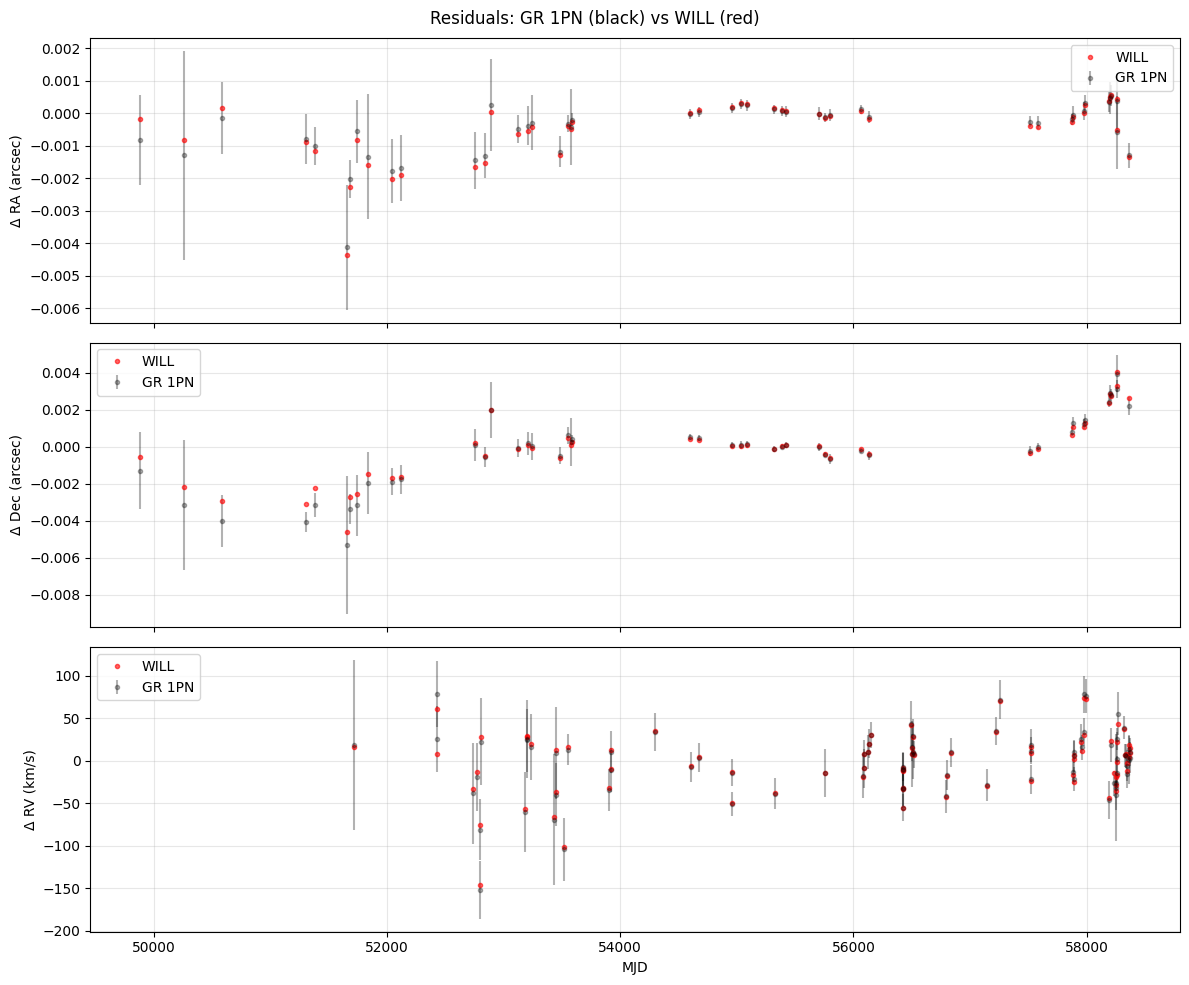

In [ ]:
"""
Diagnostic comparison of GR 1PN, GR 2PN and WILL RG models for S2.
Paste the best-fit parameters from your runs below.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =============================================================================
# 1. Data (same as in all scripts)
# =============================================================================
C_KMS = 299792.458
DAY_SEC = 86400.0

URL_ASTRO = 'https://raw.githubusercontent.com/AntonRize/WILL/main/DATA/aav8137_data_s2.csv'
URL_RV    = 'https://raw.githubusercontent.com/AntonRize/WILL/main/DATA/S0-2_DataS1_full.csv'

df_astro = pd.read_csv(URL_ASTRO).sort_values('mjd')
df_rv    = pd.read_csv(URL_RV).sort_values('MJD')

t_astro = df_astro['mjd'].values
x_obs, x_err = df_astro['x'].values, df_astro['xerr'].values
y_obs, y_err = df_astro['y'].values, df_astro['yerr'].values

t_rv   = df_rv['MJD'].values
rv_obs, rv_err = df_rv['RV_km_s'].values, df_rv['sigma_km_s'].values

# =============================================================================
# 2. Kepler solver (common)
# =============================================================================
def solve_kepler(M, e):
    E = M + e * np.sin(M)
    for _ in range(20):
        E = E - (E - e * np.sin(E) - M) / (1.0 - e * np.cos(E))
    return E

def true_anomaly(mjd, T0, P, e):
    M = 2.0 * np.pi * (mjd - T0) / P
    orbits = np.floor(M / (2.0 * np.pi))
    M_mod = M % (2.0 * np.pi)
    E_mod = solve_kepler(M_mod, e)
    nu_mod = 2.0 * np.arctan2(np.sqrt(1.0 + e) * np.sin(E_mod / 2.0),
                              np.sqrt(1.0 - e) * np.cos(E_mod / 2.0))
    return orbits * 2.0 * np.pi + (nu_mod % (2.0 * np.pi))

# =============================================================================
# 3. Model definitions (exactly as in the fit scripts)
# =============================================================================

# --- GR 1PN model (9 params, precession from K and i) ---
def gr_1PN_model(params, mjd_astro, mjd_rv):
    a_as, e, i, omega0, Omega, P, T0, V0, K = params
    a_km = (K * P * DAY_SEC * np.sqrt(1.0 - e**2)) / (2.0 * np.pi * np.sin(i))
    n = 2.0 * np.pi / (P * DAY_SEC)
    GM = n**2 * a_km**3
    delta_omega_per_orbit = (6.0 * np.pi * (K / C_KMS)**2) / np.sin(i)**2
    omega_dot = delta_omega_per_orbit / P

    def compute_state(mjd):
        nu0 = true_anomaly(mjd, T0, P, e)
        omega_t0 = omega0 + omega_dot * (mjd - T0)
        r0 = a_km * (1.0 - e**2) / (1.0 + e * np.cos(nu0))
        z0 = r0 * np.sin(i) * np.sin(nu0 + omega_t0)
        t_emit = mjd - z0 / (C_KMS * DAY_SEC)

        nu = true_anomaly(t_emit, T0, P, e)
        omega_t = omega0 + omega_dot * (t_emit - T0)
        r = a_km * (1.0 - e**2) / (1.0 + e * np.cos(nu))
        z = r * np.sin(i) * np.sin(nu + omega_t)
        x_orb_km = r * np.cos(nu)
        y_orb_km = r * np.sin(nu)
        return x_orb_km, y_orb_km, z, r, nu, omega_t

    # Astrometry
    if len(mjd_astro) > 0:
        states = [compute_state(t) for t in mjd_astro]
        x_orb_arr = np.array([s[0] for s in states])
        y_orb_arr = np.array([s[1] for s in states])
        omega_arr = np.array([s[5] for s in states])
        cos_Om, sin_Om = np.cos(Omega), np.sin(Omega)
        cos_om, sin_om = np.cos(omega_arr), np.sin(omega_arr)
        cos_i = np.cos(i)
        A = cos_Om * cos_om - sin_Om * sin_om * cos_i
        B = sin_Om * cos_om + cos_Om * sin_om * cos_i
        F = -cos_Om * sin_om - sin_Om * cos_om * cos_i
        G = -sin_Om * sin_om + cos_Om * cos_om * cos_i
        x_sky_km = B * x_orb_arr + G * y_orb_arr
        y_sky_km = A * x_orb_arr + F * y_orb_arr
        scale_km_per_as = a_km / a_as
        x_ast = x_sky_km / scale_km_per_as
        y_ast = y_sky_km / scale_km_per_as
    else:
        x_ast, y_ast = np.array([]), np.array([])

    # Radial velocity
    if len(mjd_rv) > 0:
        states_rv = [compute_state(t) for t in mjd_rv]
        r_arr = np.array([s[3] for s in states_rv])
        nu_arr = np.array([s[4] for s in states_rv])
        omega_arr = np.array([s[5] for s in states_rv])
        v_rad_kepler = K * (np.cos(nu_arr + omega_arr) + e * np.cos(omega_arr))
        v2 = GM * (2.0 / r_arr - 1.0 / a_km)
        z_grav = GM / (r_arr * C_KMS**2)
        z_td   = 0.5 * v2 / C_KMS**2
        redshift_km_s = C_KMS * (z_grav + z_td)
        rv = V0 + v_rad_kepler + redshift_km_s
    else:
        rv = np.array([])

    return x_ast, y_ast, rv

# --- WILL RG model (strict, from your script) ---
def will_model(params, mjd_astro, mjd_rv):
    a_as, e, i, omega, Omega, P, T0, V0, K = params
    # Algebraic lock
    beta_int = (K / C_KMS) / np.sin(i)
    beta_sq = (beta_int**2) * (1 - e**2)
    tau_Y_sq = 3 * beta_sq - 2 * (beta_sq**2)
    f_prec = tau_Y_sq / (1 - e**2)
    beta = np.sqrt(beta_sq)
    T_sec = P * 86400
    Rs_km = (T_sec * C_KMS * (beta**3)) / np.pi
    a_km = Rs_km / (2 * beta_sq)
    scale_km_per_as = a_km / a_as

    # Astrometry with Rømer delay (single-step)
    if len(mjd_astro) > 0:
        nu_a_0 = true_anomaly(mjd_astro, T0, P, e)
        w_shift_a_0 = f_prec * nu_a_0
        r_O_0 = a_as * (1 - e**2) / (1 + e * np.cos(nu_a_0 - w_shift_a_0))
        z_km_a = r_O_0 * scale_km_per_as * np.sin(i) * np.sin(nu_a_0 + omega + w_shift_a_0)
        t_emit_a = mjd_astro - z_km_a / (C_KMS * 86400)
        nu_a = true_anomaly(t_emit_a, T0, P, e)
        w_shift_a = f_prec * nu_a
        r_O = a_as * (1 - e**2) / (1 + e * np.cos(nu_a - w_shift_a))
        x_orb = r_O * np.cos(nu_a)
        y_orb = r_O * np.sin(nu_a)
        cos_Om, sin_Om = np.cos(Omega), np.sin(Omega)
        cos_om, sin_om = np.cos(omega), np.sin(omega)
        cos_i = np.cos(i)
        A = cos_Om * cos_om - sin_Om * sin_om * cos_i
        B = sin_Om * cos_om + cos_Om * sin_om * cos_i
        F = -cos_Om * sin_om - sin_Om * cos_om * cos_i
        G = -sin_Om * sin_om + cos_Om * cos_om * cos_i
        x_ast = B * x_orb + G * y_orb
        y_ast = A * x_orb + F * y_orb
    else:
        x_ast, y_ast = np.array([]), np.array([])

    # Radial velocity (WILL relational redshift)
    if len(mjd_rv) > 0:
        nu_r_0 = true_anomaly(mjd_rv, T0, P, e)
        w_shift_r_0 = f_prec * nu_r_0
        r_O_r_0 = a_as * (1 - e**2) / (1 + e * np.cos(nu_r_0 - w_shift_r_0))
        z_km_r = r_O_r_0 * scale_km_per_as * np.sin(i) * np.sin(nu_r_0 + omega + w_shift_r_0)
        t_emit_r = mjd_rv - z_km_r / (C_KMS * 86400)
        nu_r = true_anomaly(t_emit_r, T0, P, e)
        w_shift_r = f_prec * nu_r
        eff_w = omega + w_shift_r
        vz_classical = K * (np.cos(nu_r + eff_w) + e * np.cos(eff_w))
        r_km_r = a_km * (1 - e**2) / (1 + e * np.cos(nu_r - w_shift_r))
        kappa_o_sq = Rs_km / r_km_r
        beta_o_sq = kappa_o_sq - beta_sq      # from energy invariant
        v_relational = C_KMS * (kappa_o_sq + beta_o_sq) / 2
        rv = V0 + vz_classical + v_relational
    else:
        rv = np.array([])

    return x_ast, y_ast, rv

# =============================================================================
# 4. Best‑fit parameters
# =============================================================================
# --- GR 1PN result (from your first output) ---
gr1_params = [0.124488, 0.887826, 2.370695, 1.160650, 3.987842,
              5862.5978, 58257.6592, -15.0196, 2894.4022]

# --- GR 2PN result (from your latest run) ---
gr2_params = [0.124488, 0.887827, 2.370696, 1.160650, 3.987840,
              5862.5981, 58257.6592, -15.0191, 2894.4018]

# --- WILL result (fill exactly from your WILL output) ---
# !! Replace the placeholders with the actual values from will_model_strict !!
# Example: if you printed res.x, the order is [a_as, e, i, omega, Omega, P, T0, V0, K]
will_params = [1.24120447e-01, 8.87171396e-01, 2.37707988e+00, 1.16290521e+00, 3.99528582e+00,   # Omega approx?
               5.86248607e+03, 5.82577869e+04, -1.55461583e+01,  2.88992587e+03]           # K approx?


# =============================================================================
# 5. Predictions
# =============================================================================
x_gr1, y_gr1, rv_gr1 = gr_1PN_model(gr1_params, t_astro, t_rv)
x_gr2, y_gr2, rv_gr2 = gr_1PN_model(gr2_params, t_astro, t_rv)  # same model, diff params
x_will, y_will, rv_will = will_model(will_params, t_astro, t_rv)

# =============================================================================
# 6. χ² contributions & RMS differences
# =============================================================================
def chi2_contributions(x, y, rv, label):
    chi2_ast = np.sum(((x_obs - x)/x_err)**2) + np.sum(((y_obs - y)/y_err)**2)
    chi2_rv  = np.sum(((rv_obs - rv)/rv_err)**2)
    print(f"{label}  χ²_ast = {chi2_ast:.2f}  χ²_rv = {chi2_rv:.2f}  total = {chi2_ast+chi2_rv:.2f}")
    return chi2_ast, chi2_rv

print("\n==============================================")
print("CHI-SQUARED BREAKDOWN")
print("==============================================")
ca1, cv1 = chi2_contributions(x_gr1, y_gr1, rv_gr1, "GR 1PN")
ca2, cv2 = chi2_contributions(x_gr2, y_gr2, rv_gr2, "GR 2PN")
caw, cvw = chi2_contributions(x_will, y_will, rv_will, "WILL")

print("\nRMS of model differences (GR1PN – WILL):")
print(f"  Δx RMS = {np.sqrt(np.mean((x_gr1 - x_will)**2)):.5f} arcsec")
print(f"  Δy RMS = {np.sqrt(np.mean((y_gr1 - y_will)**2)):.5f} arcsec")
print(f"  ΔRV RMS = {np.sqrt(np.mean((rv_gr1 - rv_will)**2)):.3f} km/s")
print(f"  Typical astrometric error: xerr ~ {np.mean(x_err):.5f}, yerr ~ {np.mean(y_err):.5f} arcsec")
print(f"  Typical RV error: {np.mean(rv_err):.3f} km/s")

# =============================================================================
# 7. Residual plots
# =============================================================================
fig, axs = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axs[0].errorbar(t_astro, x_obs - x_gr1, yerr=x_err, fmt='k.', alpha=0.3, label='GR 1PN')
axs[0].plot(t_astro, x_obs - x_will, 'r.', alpha=0.6, label='WILL')
axs[0].set_ylabel('Δ RA (arcsec)')
axs[0].legend()
axs[0].grid(True, alpha=0.3)

axs[1].errorbar(t_astro, y_obs - y_gr1, yerr=y_err, fmt='k.', alpha=0.3, label='GR 1PN')
axs[1].plot(t_astro, y_obs - y_will, 'r.', alpha=0.6, label='WILL')
axs[1].set_ylabel('Δ Dec (arcsec)')
axs[1].legend()
axs[1].grid(True, alpha=0.3)

axs[2].errorbar(t_rv, rv_obs - rv_gr1, yerr=rv_err, fmt='k.', alpha=0.3, label='GR 1PN')
axs[2].plot(t_rv, rv_obs - rv_will, 'r.', alpha=0.6, label='WILL')
axs[2].set_ylabel('Δ RV (km/s)')
axs[2].set_xlabel('MJD')
axs[2].legend()
axs[2].grid(True, alpha=0.3)

plt.suptitle('Residuals: GR 1PN (black) vs WILL (red)')
plt.tight_layout()
plt.show()

In [ ]:
"""
Modular diagnostic: swap precession & redshift between GR and WILL
=================================================================
Each run fits 9 parameters. The precession law and redshift formula
are chosen independently.

Modes:
  precession : 'GR1', 'GR2', 'WILL'
  redshift   : 'GR1', 'WILL'

Output: χ² for each combination, plus reference GR1/GR1 and WILL/WILL
"""

import numpy as np
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------
# Constants & data (identical to all previous runs)
# ----------------------------------------------------------------------
C_KMS = 299792.458
DAY_SEC = 86400.0
ARCSEC_TO_RAD = np.pi / (180.0 * 3600.0)

URL_ASTRO = 'https://raw.githubusercontent.com/AntonRize/WILL/main/DATA/aav8137_data_s2.csv'
URL_RV    = 'https://raw.githubusercontent.com/AntonRize/WILL/main/DATA/S0-2_DataS1_full.csv'

df_astro = pd.read_csv(URL_ASTRO).sort_values('mjd')
df_rv    = pd.read_csv(URL_RV).sort_values('MJD')

t_astro = df_astro['mjd'].values
x_obs, x_err = df_astro['x'].values, df_astro['xerr'].values
y_obs, y_err = df_astro['y'].values, df_astro['yerr'].values

t_rv   = df_rv['MJD'].values
rv_obs, rv_err = df_rv['RV_km_s'].values, df_rv['sigma_km_s'].values

# Kepler solver
def solve_kepler(M, e):
    E = M + e * np.sin(M)
    for _ in range(20):
        E = E - (E - e * np.sin(E) - M) / (1.0 - e * np.cos(E))
    return E

def true_anomaly(mjd, T0, P, e):
    M = 2.0 * np.pi * (mjd - T0) / P
    orbits = np.floor(M / (2.0 * np.pi))
    M_mod = M % (2.0 * np.pi)
    E_mod = solve_kepler(M_mod, e)
    nu_mod = 2.0 * np.arctan2(np.sqrt(1.0 + e) * np.sin(E_mod / 2.0),
                              np.sqrt(1.0 - e) * np.cos(E_mod / 2.0))
    return orbits * 2.0 * np.pi + (nu_mod % (2.0 * np.pi))

# ----------------------------------------------------------------------
# Modular precession functions
#   Each returns: delta_omega_per_orbit (rad) for GR modes,
#                 f_prec (precession fraction per rad of true anomaly) for WILL mode
#   We'll store the type to handle inside the model.
# ----------------------------------------------------------------------
def precession_GR1(K, i, P, *args):
    """1PN GR advance Δω/orbit = 6π (K/c)² / sin²i"""
    dw_per_orbit = (6.0 * np.pi * (K / C_KMS)**2) / np.sin(i)**2
    return dw_per_orbit / P          # return advance per day

def precession_GR2(K, i, P, e, a_km, *args):
    """2PN GR advance (orbit averaged)"""
    # semi‑latus rectum (km)
    p_km = a_km * (1.0 - e**2)
    eps = ( (K / C_KMS)**2 / np.sin(i)**2 ) * (P * DAY_SEC)**2 / (4*np.pi**2) / p_km  # equivalent to GM/(c² p)
    # Actually, simpler: compute GM from K,i,P,e
    n = 2.0 * np.pi / (P * DAY_SEC)
    GM = n**2 * a_km**3
    eps = GM / (C_KMS**2 * p_km)
    dw_per_orbit = 6.0 * np.pi * eps * (1.0 + 0.5 * eps * (9.0 + e**2))
    return dw_per_orbit / P

def precession_WILL(K, i, P, e, *args):
    """WILL algebraic lock: f_prec = τY²/(1-e²)  (advance per rad of true anomaly)"""
    beta_int = (K / C_KMS) / np.sin(i)
    beta_sq = (beta_int**2) * (1 - e**2)
    tauY_sq = 3 * beta_sq - 2 * beta_sq**2
    f_prec = tauY_sq / (1 - e**2)
    return f_prec                      # dimensionless, used as: omega = omega0 + f_prec * nu

# ----------------------------------------------------------------------
# Modular redshift functions
#   Each returns: redshift in km/s
# ----------------------------------------------------------------------
def redshift_GR1(GM, r, a_km, *args):
    """1PN gravitational + transverse Doppler (km/s)"""
    v2 = GM * (2.0 / r - 1.0 / a_km)          # km²/s²
    z_grav = GM / (r * C_KMS**2)
    z_td   = 0.5 * v2 / C_KMS**2
    return C_KMS * (z_grav + z_td)

def redshift_WILL(Rs, r, beta_sq, *args):
    """WILL relational redshift: (c/2)(κ² + β²) with κ² = Rs/r, β² = κ² - β²_global"""
    kappa_o_sq = Rs / r
    # β_o_sq from energy invariant: β_o² = κ_o² - β²_global
    beta_o_sq = kappa_o_sq - beta_sq
    return C_KMS * (kappa_o_sq + beta_o_sq) / 2.0

# ----------------------------------------------------------------------
# Generic model with selectable precession & redshift modes
# ----------------------------------------------------------------------
def generic_model(params, mjd_astro, mjd_rv, prec_mode, red_mode):
    a_as, e, i, omega0, Omega, P, T0, V0, K = params

    # Derived quantities common to all
    a_km = (K * P * DAY_SEC * np.sqrt(1.0 - e**2)) / (2.0 * np.pi * np.sin(i))
    n = 2.0 * np.pi / (P * DAY_SEC)
    GM = n**2 * a_km**3          # km³/s²

    # WILL‑specific quantities if needed
    beta_int = (K / C_KMS) / np.sin(i)
    beta_sq = (beta_int**2) * (1 - e**2)
    Rs_km = (P * DAY_SEC * C_KMS * (beta_sq**1.5)) / np.pi   # Rs = T c β³/π

    # Precession advance per day (or fraction)
    if prec_mode == 'GR1':
        omega_dot = precession_GR1(K, i, P)
    elif prec_mode == 'GR2':
        omega_dot = precession_GR2(K, i, P, e, a_km)
    elif prec_mode == 'WILL':
        f_prec = precession_WILL(K, i, P, e)
        # For WILL mode, omega is advanced by f_prec * nu, not a time‑dependent omega_dot
        # We'll handle that inside compute_state.
    else:
        raise ValueError("Unknown prec_mode")

    # Redshift function
    def redshift_call(r):
        if red_mode == 'GR1':
            return redshift_GR1(GM, r, a_km)
        elif red_mode == 'WILL':
            return redshift_WILL(Rs_km, r, beta_sq)
        else:
            raise ValueError("Unknown red_mode")

    # Helper to compute state at a given observation time (MJD)
    def compute_state(mjd):
        if prec_mode in ('GR1', 'GR2'):
            # Time‑dependent omega
            omega_t = omega0 + omega_dot * (mjd - T0)
            nu = true_anomaly(mjd, T0, P, e)   # initial guess without Rømer
            # 1st Rømer iteration (same as before)
            r0 = a_km * (1.0 - e**2) / (1.0 + e * np.cos(nu))
            z0 = r0 * np.sin(i) * np.sin(nu + omega_t)
            t_emit = mjd - z0 / (C_KMS * DAY_SEC)
            nu = true_anomaly(t_emit, T0, P, e)
            omega_t = omega0 + omega_dot * (t_emit - T0)
        else:   # WILL precession (omega advances with true anomaly)
            # ω = ω0 + f_prec * nu
            # We'll directly compute nu and omega together later, but still need Rømer.
            nu0 = true_anomaly(mjd, T0, P, e)
            omega_t0 = omega0 + f_prec * nu0
            r0 = a_km * (1.0 - e**2) / (1.0 + e * np.cos(nu0))
            z0 = r0 * np.sin(i) * np.sin(nu0 + omega_t0)
            t_emit = mjd - z0 / (C_KMS * DAY_SEC)
            nu = true_anomaly(t_emit, T0, P, e)
            omega_t = omega0 + f_prec * nu

        r = a_km * (1.0 - e**2) / (1.0 + e * np.cos(nu))
        z = r * np.sin(i) * np.sin(nu + omega_t)
        x_orb_km = r * np.cos(nu)
        y_orb_km = r * np.sin(nu)
        return x_orb_km, y_orb_km, z, r, nu, omega_t

    # Astrometry
    x_mod, y_mod = np.array([]), np.array([])
    if len(mjd_astro) > 0:
        states = [compute_state(t) for t in mjd_astro]
        x_orb_arr = np.array([s[0] for s in states])
        y_orb_arr = np.array([s[1] for s in states])
        om_arr = np.array([s[5] for s in states])
        cos_Om, sin_Om = np.cos(Omega), np.sin(Omega)
        cos_om, sin_om = np.cos(om_arr), np.sin(om_arr)
        cos_i = np.cos(i)
        A = cos_Om * cos_om - sin_Om * sin_om * cos_i
        B = sin_Om * cos_om + cos_Om * sin_om * cos_i
        F = -cos_Om * sin_om - sin_Om * cos_om * cos_i
        G = -sin_Om * sin_om + cos_Om * cos_om * cos_i
        x_sky_km = B * x_orb_arr + G * y_orb_arr
        y_sky_km = A * x_orb_arr + F * y_orb_arr
        scale_km_per_as = a_km / a_as
        x_mod = x_sky_km / scale_km_per_as
        y_mod = y_sky_km / scale_km_per_as

    # Radial velocity
    rv_mod = np.array([])
    if len(mjd_rv) > 0:
        states_rv = [compute_state(t) for t in mjd_rv]
        r_arr = np.array([s[3] for s in states_rv])
        nu_arr = np.array([s[4] for s in states_rv])
        om_arr = np.array([s[5] for s in states_rv])
        # Classical Keplerian
        vz_classical = K * (np.cos(nu_arr + om_arr) + e * np.cos(om_arr))
        # Relativistic redshift (chosen mode)
        red = np.array([redshift_call(r) for r in r_arr])
        rv_mod = V0 + vz_classical + red

    return x_mod, y_mod, rv_mod

# ----------------------------------------------------------------------
# Objective function for a given combination
# ----------------------------------------------------------------------
def make_chi2(prec_mode, red_mode):
    def chi2(params):
        x_m, y_m, rv_m = generic_model(params, t_astro, t_rv, prec_mode, red_mode)
        chi2_ast = np.sum(((x_obs - x_m)/x_err)**2 + ((y_obs - y_m)/y_err)**2)
        chi2_rv  = np.sum(((rv_obs - rv_m)/rv_err)**2)
        return chi2_ast + chi2_rv
    return chi2

# ----------------------------------------------------------------------
# Fit a given combination
# ----------------------------------------------------------------------
def fit_combination(prec_mode, red_mode, label, p0, bounds):
    chi2_func = make_chi2(prec_mode, red_mode)
    print(f"\nFitting {label:20s} ...", end='')
    res_nm = minimize(chi2_func, p0, bounds=bounds, method='Nelder-Mead',
                      options={'maxiter': 25000, 'xatol': 1e-10, 'fatol': 1e-10})
    res = minimize(chi2_func, res_nm.x, bounds=bounds, method='L-BFGS-B')
    print(f" χ² = {res.fun:.2f}")
    return res.fun, res.x

# =========================================================================
# MAIN: Run all combinations
# =========================================================================
# Initial guess & bounds (same as before)
p0 = [0.124, 0.885, 2.36, 1.15, 3.98, 5860.0, 58258.0, -15.0, 3100.0]
bounds = [
    (0.10, 0.15), (0.80, 0.95), (0, np.pi), (0, 2*np.pi),
    (0, 2*np.pi), (5800, 5950), (58100, 58400), (-200, 200), (1000, 5000)
]

combinations = [
    ('GR1',  'GR1',  "GR 1PN prec + GR 1PN redshift"),
    ('GR2',  'GR1',  "GR 2PN prec + GR 1PN redshift"),
    ('GR1',  'WILL', "GR 1PN prec + WILL redshift"),
    ('GR2',  'WILL', "GR 2PN prec + WILL redshift"),
    ('WILL', 'GR1',  "WILL prec + GR 1PN redshift"),
    ('WILL', 'WILL', "WILL prec + WILL redshift (full WILL)")
]

results = {}
for prec, red, desc in combinations:
    chi2_val, best_params = fit_combination(prec, red, desc, p0, bounds)
    results[desc] = chi2_val

# Print summary table
print("\n" + "="*70)
print("MODULAR COMPARISON (PRECESSION vs REDSHIFT)")
print("="*70)
print(f"{'Model':40s} {'Total χ²':>10}")
print("-"*70)
for desc, chi2 in results.items():
    print(f"{desc:40s} {chi2:10.2f}")
print("-"*70)
delta_gr = results["GR 1PN prec + GR 1PN redshift"]
print("\nDifferences relative to GR 1PN/1PN:")
for desc, chi2 in results.items():
    print(f"  {desc:40s} Δχ² = {chi2 - delta_gr:+.2f}")


Fitting GR 1PN prec + GR 1PN redshift ... χ² = 800.81

Fitting GR 2PN prec + GR 1PN redshift ... χ² = 800.84

Fitting GR 1PN prec + WILL redshift ... χ² = 800.81

Fitting GR 2PN prec + WILL redshift ... χ² = 800.84

Fitting WILL prec + GR 1PN redshift ... χ² = 809.92

Fitting WILL prec + WILL redshift (full WILL) ... χ² = 809.92

MODULAR COMPARISON (PRECESSION vs REDSHIFT)
Model                                      Total χ²
----------------------------------------------------------------------
GR 1PN prec + GR 1PN redshift                800.81
GR 2PN prec + GR 1PN redshift                800.84
GR 1PN prec + WILL redshift                  800.81
GR 2PN prec + WILL redshift                  800.84
WILL prec + GR 1PN redshift                  809.92
WILL prec + WILL redshift (full WILL)        809.92
----------------------------------------------------------------------

Differences relative to GR 1PN/1PN:
  GR 1PN prec + GR 1PN redshift            Δχ² = +0.00
  GR 2PN prec + GR 1PN re

In [ ]:
"""
Modular diagnostic (CORRECTED) – swap precession & redshift between GR and WILL
================================================================================
Key fix:
  In WILL mode, the semi‑major axis a_km is derived from the algebraic lock
  (R_s and beta²), NOT from Kepler's law.
"""

import numpy as np
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------
# Constants & data
# ----------------------------------------------------------------------
C_KMS = 299792.458
DAY_SEC = 86400.0
ARCSEC_TO_RAD = np.pi / (180.0 * 3600.0)

URL_ASTRO = 'https://raw.githubusercontent.com/AntonRize/WILL/main/DATA/aav8137_data_s2.csv'
URL_RV    = 'https://raw.githubusercontent.com/AntonRize/WILL/main/DATA/S0-2_DataS1_full.csv'

df_astro = pd.read_csv(URL_ASTRO).sort_values('mjd')
df_rv    = pd.read_csv(URL_RV).sort_values('MJD')

t_astro = df_astro['mjd'].values
x_obs, x_err = df_astro['x'].values, df_astro['xerr'].values
y_obs, y_err = df_astro['y'].values, df_astro['yerr'].values

t_rv   = df_rv['MJD'].values
rv_obs, rv_err = df_rv['RV_km_s'].values, df_rv['sigma_km_s'].values

# Kepler solver
def solve_kepler(M, e):
    E = M + e * np.sin(M)
    for _ in range(20):
        E = E - (E - e * np.sin(E) - M) / (1.0 - e * np.cos(E))
    return E

def true_anomaly(mjd, T0, P, e):
    M = 2.0 * np.pi * (mjd - T0) / P
    orbits = np.floor(M / (2.0 * np.pi))
    M_mod = M % (2.0 * np.pi)
    E_mod = solve_kepler(M_mod, e)
    nu_mod = 2.0 * np.arctan2(np.sqrt(1.0 + e) * np.sin(E_mod / 2.0),
                              np.sqrt(1.0 - e) * np.cos(E_mod / 2.0))
    return orbits * 2.0 * np.pi + (nu_mod % (2.0 * np.pi))

# ----------------------------------------------------------------------
# Precession & redshift helpers (same as before)
# ----------------------------------------------------------------------
def precession_GR1(K, i, P):
    dw = (6.0 * np.pi * (K / C_KMS)**2) / np.sin(i)**2
    return dw / P

def precession_GR2(K, i, P, e, a_km):
    n = 2.0 * np.pi / (P * DAY_SEC)
    GM = n**2 * a_km**3
    p_km = a_km * (1 - e**2)
    eps = GM / (C_KMS**2 * p_km)
    dw = 6.0 * np.pi * eps * (1.0 + 0.5 * eps * (9.0 + e**2))
    return dw / P

def precession_WILL(K, i, P, e):
    beta_int = (K / C_KMS) / np.sin(i)
    beta_sq = (beta_int**2) * (1 - e**2)
    tauY_sq = 3 * beta_sq - 2 * beta_sq**2
    return tauY_sq / (1 - e**2)

def redshift_GR1(GM, r, a_km):
    v2 = GM * (2.0 / r - 1.0 / a_km)
    z_grav = GM / (r * C_KMS**2)
    z_td   = 0.5 * v2 / C_KMS**2
    return C_KMS * (z_grav + z_td)

def redshift_WILL(Rs, r, beta_sq):
    kappa_o_sq = Rs / r
    beta_o_sq = kappa_o_sq - beta_sq
    return C_KMS * (kappa_o_sq + beta_o_sq) / 2.0

# ----------------------------------------------------------------------
# Generic model – NOW WITH MODE‑DEPENDENT SCALE
# ----------------------------------------------------------------------
def generic_model(params, mjd_astro, mjd_rv, prec_mode, red_mode):
    a_as, e, i, omega0, Omega, P, T0, V0, K = params

    # -- WILL‑specific scale quantities (needed if any mode is WILL) --
    beta_int = (K / C_KMS) / np.sin(i)
    beta_sq = (beta_int**2) * (1 - e**2)
    period_sec = P * DAY_SEC
    Rs_km = (period_sec * C_KMS * (beta_sq**1.5)) / np.pi   # Rs = T c β³ / π
    a_km_will = Rs_km / (2.0 * beta_sq)                     # a from closure

    # -- Choose which a_km to use for astrometry/Rømer --
    if prec_mode in ('GR1', 'GR2'):
        # Keplerian semi‑major axis
        a_km = (K * P * DAY_SEC * np.sqrt(1.0 - e**2)) / (2.0 * np.pi * np.sin(i))
    else:  # WILL precession – use the relational a_km
        a_km = a_km_will

    # -- Gravitational mass (only needed for GR redshift) --
    n = 2.0 * np.pi / period_sec
    GM = n**2 * a_km**3          # consistent with the chosen a_km

    # -- Precession advance (time derivative or fractional) --
    if prec_mode == 'GR1':
        omega_dot = precession_GR1(K, i, P)
    elif prec_mode == 'GR2':
        omega_dot = precession_GR2(K, i, P, e, a_km)
    elif prec_mode == 'WILL':
        f_prec = precession_WILL(K, i, P, e)
    else:
        raise ValueError

    # -- Redshift function --
    def redshift_call(r):
        if red_mode == 'GR1':
            return redshift_GR1(GM, r, a_km)
        else:
            return redshift_WILL(Rs_km, r, beta_sq)

    # -- State computer --
    def compute_state(mjd):
        if prec_mode in ('GR1', 'GR2'):
            # time‑dependent ω
            nu0 = true_anomaly(mjd, T0, P, e)
            omega_t0 = omega0 + omega_dot * (mjd - T0)
            r0 = a_km * (1.0 - e**2) / (1.0 + e * np.cos(nu0))
            z0 = r0 * np.sin(i) * np.sin(nu0 + omega_t0)
            t_emit = mjd - z0 / (C_KMS * DAY_SEC)
            nu = true_anomaly(t_emit, T0, P, e)
            omega_t = omega0 + omega_dot * (t_emit - T0)
        else:   # WILL: ω advances with true anomaly
            nu0 = true_anomaly(mjd, T0, P, e)
            omega_t0 = omega0 + f_prec * nu0
            r0 = a_km * (1.0 - e**2) / (1.0 + e * np.cos(nu0))
            z0 = r0 * np.sin(i) * np.sin(nu0 + omega_t0)
            t_emit = mjd - z0 / (C_KMS * DAY_SEC)
            nu = true_anomaly(t_emit, T0, P, e)
            omega_t = omega0 + f_prec * nu

        r = a_km * (1.0 - e**2) / (1.0 + e * np.cos(nu))
        z = r * np.sin(i) * np.sin(nu + omega_t)
        x_orb, y_orb = r * np.cos(nu), r * np.sin(nu)
        return x_orb, y_orb, z, r, nu, omega_t

    # -- Astrometry --
    x_mod, y_mod = np.array([]), np.array([])
    if len(mjd_astro) > 0:
        states = [compute_state(t) for t in mjd_astro]
        x_orb_arr = np.array([s[0] for s in states])
        y_orb_arr = np.array([s[1] for s in states])
        om_arr    = np.array([s[5] for s in states])
        cos_Om, sin_Om = np.cos(Omega), np.sin(Omega)
        cos_om, sin_om = np.cos(om_arr), np.sin(om_arr)
        cos_i = np.cos(i)
        A = cos_Om * cos_om - sin_Om * sin_om * cos_i
        B = sin_Om * cos_om + cos_Om * sin_om * cos_i
        F = -cos_Om * sin_om - sin_Om * cos_om * cos_i
        G = -sin_Om * sin_om + cos_Om * cos_om * cos_i
        x_sky_km = B * x_orb_arr + G * y_orb_arr
        y_sky_km = A * x_orb_arr + F * y_orb_arr
        scale_km_per_as = a_km / a_as
        x_mod = x_sky_km / scale_km_per_as
        y_mod = y_sky_km / scale_km_per_as

    # -- Radial velocity --
    rv_mod = np.array([])
    if len(mjd_rv) > 0:
        states_rv = [compute_state(t) for t in mjd_rv]
        r_arr  = np.array([s[3] for s in states_rv])
        nu_arr = np.array([s[4] for s in states_rv])
        om_arr = np.array([s[5] for s in states_rv])
        vz_classical = K * (np.cos(nu_arr + om_arr) + e * np.cos(om_arr))
        red = np.array([redshift_call(r) for r in r_arr])
        rv_mod = V0 + vz_classical + red

    return x_mod, y_mod, rv_mod

# ----------------------------------------------------------------------
# Fit driver
# ----------------------------------------------------------------------
def make_chi2(prec_mode, red_mode):
    def chi2(params):
        x_m, y_m, rv_m = generic_model(params, t_astro, t_rv, prec_mode, red_mode)
        chi2_ast = np.sum(((x_obs - x_m)/x_err)**2 + ((y_obs - y_m)/y_err)**2)
        chi2_rv  = np.sum(((rv_obs - rv_m)/rv_err)**2)
        return chi2_ast + chi2_rv
    return chi2

def fit_combination(prec, red, label, p0, bounds):
    chi2_func = make_chi2(prec, red)
    print(f"\nFitting {label:20s} ...", end='')
    res_nm = minimize(chi2_func, p0, bounds=bounds, method='Nelder-Mead',
                      options={'maxiter': 25000})
    res = minimize(chi2_func, res_nm.x, bounds=bounds, method='L-BFGS-B')
    print(f" χ² = {res.fun:.2f}")
    return res.fun, res.x

# =============================================================================
# Run all combinations
# =============================================================================
p0 = [0.124, 0.885, 2.36, 1.15, 3.98, 5860.0, 58258.0, -15.0, 3100.0]
bounds = [(0.10, 0.15), (0.80, 0.95), (0, np.pi), (0, 2*np.pi),
          (0, 2*np.pi), (5800, 5950), (58100, 58400), (-200, 200), (1000, 5000)]

combos = [
    ('GR1',  'GR1',  "GR 1PN prec + GR 1PN redshift"),
    ('GR2',  'GR1',  "GR 2PN prec + GR 1PN redshift"),
    ('GR1',  'WILL', "GR 1PN prec + WILL redshift"),
    ('GR2',  'WILL', "GR 2PN prec + WILL redshift"),
    ('WILL', 'GR1',  "WILL prec + GR 1PN redshift"),
    ('WILL', 'WILL', "WILL prec + WILL redshift (full WILL)"),
]

results = {}
for prec, red, desc in combos:
    chi2_val, best_par = fit_combination(prec, red, desc, p0, bounds)
    results[desc] = chi2_val

print("\n" + "="*70)
print("MODULAR COMPARISON (PRECESSION vs REDSHIFT) – CORRECTED")
print("="*70)
print(f"{'Model':40s} {'Total χ²':>10}")
print("-"*70)
for desc, chi2 in results.items():
    print(f"{desc:40s} {chi2:10.2f}")
print("-"*70)
delta_gr = results["GR 1PN prec + GR 1PN redshift"]
print("\nDifferences relative to GR 1PN/1PN:")
for desc, chi2 in results.items():
    print(f"  {desc:40s} Δχ² = {chi2 - delta_gr:+.2f}")


Fitting GR 1PN prec + GR 1PN redshift ... χ² = 800.81

Fitting GR 2PN prec + GR 1PN redshift ... χ² = 800.84

Fitting GR 1PN prec + WILL redshift ... χ² = 800.81

Fitting GR 2PN prec + WILL redshift ... χ² = 800.84

Fitting WILL prec + GR 1PN redshift ... χ² = 809.92

Fitting WILL prec + WILL redshift (full WILL) ... χ² = 809.92

MODULAR COMPARISON (PRECESSION vs REDSHIFT) – CORRECTED
Model                                      Total χ²
----------------------------------------------------------------------
GR 1PN prec + GR 1PN redshift                800.81
GR 2PN prec + GR 1PN redshift                800.84
GR 1PN prec + WILL redshift                  800.81
GR 2PN prec + WILL redshift                  800.84
WILL prec + GR 1PN redshift                  809.92
WILL prec + WILL redshift (full WILL)        809.92
----------------------------------------------------------------------

Differences relative to GR 1PN/1PN:
  GR 1PN prec + GR 1PN redshift            Δχ² = +0.00
  GR 2PN prec

In [ ]:
"""
Hybrid Model: WILL geometry (rigid rotation via nu-dependent ω_shift)
with GR 1PN precession magnitude.

Same 9 parameters, same Rømer delay, same relational redshift.
Only difference: f_prec = 3 (K/c)² / sin²i  (i.e. GR 1PN Δω/orbit = 2π f_prec)
"""

import numpy as np
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------
# Constants & data
# ----------------------------------------------------------------------
C_KMS = 299792.458
DAY_SEC = 86400.0
AU_KM = 149597870.7
MSUN_GM = (1.32712440018e20 / (C_KMS*1000)**2) / 1000

URL_ASTRO = 'https://raw.githubusercontent.com/AntonRize/WILL/main/DATA/aav8137_data_s2.csv'
URL_RV    = 'https://raw.githubusercontent.com/AntonRize/WILL/main/DATA/S0-2_DataS1_full.csv'

df_astro = pd.read_csv(URL_ASTRO).sort_values('mjd')
df_rv    = pd.read_csv(URL_RV).sort_values('MJD')

m_a = df_astro['mjd'].values
x_obs, x_err = df_astro['x'].values, df_astro['xerr'].values
y_obs, y_err = df_astro['y'].values, df_astro['yerr'].values

m_r = df_rv['MJD'].values
rv_obs, rv_err = df_rv['RV_km_s'].values, df_rv['sigma_km_s'].values

# Kepler solver (exactly as in WILL original)
def solve_kepler(M, e):
    E = np.copy(M)
    for _ in range(50):
        E = E - (E - e * np.sin(E) - M) / (1 - e * np.cos(E))
    return E

def get_nu(mjd, T0, P, e):
    M = 2 * np.pi * (mjd - T0) / P
    orbits = np.floor(M / (2 * np.pi))
    M_mod = M % (2 * np.pi)
    E_mod = solve_kepler(M_mod, e)
    nu_mod = 2 * np.arctan2(np.sqrt(1 + e) * np.sin(E_mod / 2),
                            np.sqrt(1 - e) * np.cos(E_mod / 2))
    return orbits * 2 * np.pi + (nu_mod % (2 * np.pi))

# ----------------------------------------------------------------------
# Hybrid model: WILL astrometry + Rømer, WILL redshift,
# but f_prec from GR 1PN magnitude.
# ----------------------------------------------------------------------
def hybrid_model(params, mjd_a, mjd_r):
    a_as, e, i, omega, Omega, P, T0, V0, K = params

    # -- GR 1PN precession magnitude (per radian of true anomaly) --
    # Δω/orbit = 6π (K/c)² / sin²i   =>  f_prec = Δω/orbit / (2π) = 3 (K/c)² / sin²i
    f_prec = 3.0 * (K / C_KMS)**2 / np.sin(i)**2

    # -- WILL algebraic scale (still relational, needed for redshift and a_km) --
    beta_int = (K / C_KMS) / np.sin(i)
    beta_sq = (beta_int**2) * (1 - e**2)
    beta = np.sqrt(beta_sq)
    T_sec = P * 86400
    Rs_km = (T_sec * C_KMS * (beta**3)) / np.pi   # relational Rs
    a_km = Rs_km / (2 * beta_sq)                  # from closure
    scale_km_per_as = a_km / a_as

    # -- Astrometry (exactly as WILL, but with GR f_prec) --
    nu_a_0 = get_nu(mjd_a, T0, P, e)
    w_shift_a_0 = f_prec * nu_a_0
    r_O_0 = a_as * (1 - e**2) / (1 + e * np.cos(nu_a_0 - w_shift_a_0))
    z_km_a = r_O_0 * scale_km_per_as * np.sin(i) * np.sin(nu_a_0 + omega + w_shift_a_0)
    t_emit_a = mjd_a - z_km_a / (C_KMS * 86400)

    nu_a = get_nu(t_emit_a, T0, P, e)
    w_shift_a = f_prec * nu_a
    r_O = a_as * (1 - e**2) / (1 + e * np.cos(nu_a - w_shift_a))
    x_orb = r_O * np.cos(nu_a)
    y_orb = r_O * np.sin(nu_a)

    A = np.cos(Omega)*np.cos(omega) - np.sin(Omega)*np.sin(omega)*np.cos(i)
    B = np.sin(Omega)*np.cos(omega) + np.cos(Omega)*np.sin(omega)*np.cos(i)
    F = -np.cos(Omega)*np.sin(omega) - np.sin(Omega)*np.cos(omega)*np.cos(i)
    G = -np.sin(Omega)*np.sin(omega) + np.cos(Omega)*np.cos(omega)*np.cos(i)

    x_sky = B * x_orb + G * y_orb
    y_sky = A * x_orb + F * y_orb

    # -- Radial velocity (WILL relational redshift, same as original) --
    rv_pred = np.array([])
    if len(mjd_r) > 0:
        nu_r_0 = get_nu(mjd_r, T0, P, e)
        w_shift_r_0 = f_prec * nu_r_0
        r_O_r_0 = a_as * (1 - e**2) / (1 + e * np.cos(nu_r_0 - w_shift_r_0))
        z_km_r = r_O_r_0 * scale_km_per_as * np.sin(i) * np.sin(nu_r_0 + omega + w_shift_r_0)
        t_emit_r = mjd_r - z_km_r / (C_KMS * 86400)

        nu_r = get_nu(t_emit_r, T0, P, e)
        w_shift_r = f_prec * nu_r
        eff_w = omega + w_shift_r

        vz_classical = K * (np.cos(nu_r + eff_w) + e * np.cos(eff_w))
        r_km_r = a_km * (1 - e**2) / (1 + e * np.cos(nu_r - w_shift_r))
        kappa_o_sq = Rs_km / r_km_r
        beta_o_sq = kappa_o_sq - beta_sq
        v_relational = C_KMS * (kappa_o_sq + beta_o_sq) / 2

        rv_pred = V0 + vz_classical + v_relational

    return x_sky, y_sky, rv_pred, beta_sq, f_prec

# Objective
def chi2(params):
    xs, ys, rv, _, _ = hybrid_model(params, m_a, m_r)
    return np.sum(((x_obs-xs)/x_err)**2) + np.sum(((y_obs-ys)/y_err)**2) + np.sum(((rv_obs-rv)/rv_err)**2)

# Fit (same initial guess and bounds as before)
p0 = [0.124, 0.885, 2.36, 1.15, 3.98, 5860, 58258, -10.0, 3000]
bounds = [(0.10, 0.15), (0.80, 0.95), (0, np.pi), (0, 2*np.pi), (0, 2*np.pi),
          (5800, 5950), (58100, 58400), (-200, 200), (1000, 5000)]

print(">>> Fitting Hybrid (WILL geometry + GR 1PN precession)...")
res_nm = minimize(chi2, p0, bounds=bounds, method='Nelder-Mead', options={'maxiter': 25000})
res = minimize(chi2, res_nm.x, bounds=bounds, method='L-BFGS-B')

a_as, e, i, omega, Omega, P_days, T0, V0, K = res.x
chi2_val = res.fun
_, _, _, beta_sq, f_prec = hybrid_model(res.x, np.array([T0]), np.array([]))

beta = np.sqrt(beta_sq)
T_sec = P_days * 86400
Rs_km = (T_sec * C_KMS * (beta**3)) / np.pi
a_km = Rs_km / (2 * beta_sq)
a_au = a_km / AU_KM
R0_pc = (a_km / a_as) / 3.08567758e13 * (180*3600/np.pi)
Mass_Msun = (Rs_km / 2) / MSUN_GM

print("\n" + "="*65)
print("HYBRID MODEL: WILL geometry + GR 1PN precession magnitude")
print("="*65)
print(f"Fit Quality (Chi-Squared):       {chi2_val:.4f}")
print("-" * 65)
print(f"Precession f_prec (GR 1PN):      {f_prec:.8f}")
print(f"Relational Beta (beta):          {beta:.8f}")
print(f"Angular Semi-major Axis (a_as):  {a_as:.6f} arcsec")
print(f"Eccentricity (e):                {e:.6f}")
print(f"Inclination (i):                 {i:.6f} rad")
print(f"Argument of Periapsis (omega):   {omega:.6f} rad")
print(f"Period (T):                      {P_days:.4f} days")
print(f"Systemic Velocity (V0):          {V0:.4f} km/s")
print(f"K:                               {K:.4f} km/s")
print("-" * 65)
print(f"Derived Rs:                      {Rs_km:.2f} km")
print(f"Derived a:                       {a_au:.6f} AU")
print(f"Derived R0:                      {R0_pc:.2f} pc")
print(f"Derived Mass:                    {Mass_Msun/1e6:.4f} Million M_sun")
print("="*65)

>>> Fitting Hybrid (WILL geometry + GR 1PN precession)...

HYBRID MODEL: WILL geometry + GR 1PN precession magnitude
Fit Quality (Chi-Squared):       727.2036
-----------------------------------------------------------------
Precession f_prec (GR 1PN):      0.00058185
Relational Beta (beta):          0.00642627
Angular Semi-major Axis (a_as):  0.124120 arcsec
Eccentricity (e):                0.887171
Inclination (i):                 2.377080 rad
Argument of Periapsis (omega):   1.162905 rad
Period (T):                      5862.4861 days
Systemic Velocity (V0):          -15.5461 km/s
K:                               2889.9256 km/s
-----------------------------------------------------------------
Derived Rs:                      12827530.83 km
Derived a:                       1038.173356 AU
Derived R0:                      8364.24 pc
Derived Mass:                    4.3435 Million M_sun
